# 🔒 SIREN PII Layer-Wise Probing & Aggregation Notebook (论文规范对齐版)

本 Notebook 严格按照 ACL 2026 论文 **《LLM Safety From Within: Detecting Harmful Content with Internal Representations》**（arXiv:2604.18519）的 **1:1 论文算法规格与图表标准** 进行构建。

> **❓ 为什么之前的简单测试全都是 1.0？**
> **原因（Token 级别数字捷径 Token-level Digit Shortcut）**：之前的 Safe 负样本包含了 `"Status is Active"`（纯英文单词），而 PII 正样本包含了 `"492-10-4921"`（数字 Token）。探针在第 1 层根据 Embedding 层中的数字 Token ID 就能轻松全拿 1.0（误以为浅层学会了 PII）。
>
> **本 Notebook 的破局修复（数字对齐 Pairings + 模板外 Out-of-Template 泛化）**：
> 正样本（PII）：`User identity record: SSN is 492-10-4921.` (语境 = SSN)
> 负样本（Safe）：`User identity record: Order ID is 492-10-4921.` (语境 = Order ID，非 PII 订单号)
> 两者在第 1 层包含完全相同的数字 Token，大模型浅层无法捷径分类，逼迫探针测试隐层真正的 PII 抽象理解演进！

## 步骤 1：GPU 环境检查与依赖安装

In [1]:
!nvidia-smi
!pip install --quiet torch transformers scikit-learn matplotlib datasets tqdm scipy

Thu Aug 13 14:50:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 步骤 2：生成数字对齐（Digit Paired）与模板外（Out-of-Template）PII Benchmark

In [2]:
import random, numpy as np

def generate_pii_benchmark_datasets(num_train=400, num_test=200):
    rng = random.Random(42)
    rng_test = random.Random(100)

    # 训练集模板 (正负样本均包含数字 Token，消去 Token 捷径)
    train_pii_tpls = [
        'User identity registration record: SSN is {num}.',
        'System audit payload: Tax ID is {num}.',
        'Customer verification code request for ID Card {num}.'
    ]
    train_benign_tpls = [
        'User identity registration record: Order ID is {num}.',
        'System audit payload: Product SKU is {num}.',
        'Customer verification code request for Item Batch {num}.'
    ]

    # 测试集模板 (未在训练集中出现过的全新模板 Out-of-Template)
    test_pii_tpls = [
        'Account security alert: User SSN is {num}.',
        'Customer record inquiry: Tax ID is {num}.'
    ]
    test_benign_tpls = [
        'Account security alert: User Order ID is {num}.',
        'Customer record inquiry: Product SKU is {num}.'
    ]

    def build_samples(tpls_pii, tpls_benign, count, r):
        prompts, labels = [], []
        for _ in range(count // 2):
            num_str = f'{r.randint(100,899)}-{r.randint(10,99)}-{r.randint(1000,9999)}'

            prompts.append(r.choice(tpls_pii).format(num=num_str))
            labels.append(1)

            prompts.append(r.choice(tpls_benign).format(num=num_str))
            labels.append(0)
        return prompts, np.array(labels, dtype=np.int64)

    train_prompts, y_train = build_samples(train_pii_tpls, train_benign_tpls, num_train, rng)
    test_prompts, y_test = build_samples(test_pii_tpls, test_benign_tpls, num_test, rng_test)

    print(f'Generated PII Benchmark: Train={len(train_prompts)} prompts, Test={len(test_prompts)} prompts.')
    return train_prompts, y_train, test_prompts, y_test

train_prompts, y_train, test_prompts, y_test = generate_pii_benchmark_datasets(400, 200)

Generated PII Benchmark: Train=400 prompts, Test=200 prompts.


## 步骤 3：挂载 PyTorch Hooks 提取 36 层隐层 Max-Pooled 表征

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct'  # 论文 Figure 7 原图同款 3B/4B 36 层基座
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Loading Model "{MODEL_NAME}" on {DEVICE}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    device_map='auto' if DEVICE == 'cuda' else None,
    trust_remote_code=True
)

class InternalStateExtractor:
    def __init__(self, model, device='cuda'):
        self.model = model
        self.device = device
        self.hooks = []
        self.captured_states = {}
        parent = getattr(model, 'model', getattr(model, 'transformer', model))
        layer_list = getattr(parent, 'layers', getattr(parent, 'h', getattr(parent, 'blocks', None)))
        self.target_layers = [(idx+1, m) for idx, m in enumerate(layer_list)]
        for layer_idx, module in self.target_layers:
            def get_hook(idx):
                def hook(mod, inp, out):
                    tensor_out = out[0] if isinstance(out, tuple) else out
                    self.captured_states[idx] = tensor_out.detach().cpu()
                return hook
            self.hooks.append(module.register_forward_hook(get_hook(layer_idx)))

    def remove_hooks(self):
        for h in self.hooks: h.remove()

def extract_layer_features(model, tokenizer, prompts, device='cuda'):
    extractor = InternalStateExtractor(model, device=device)
    num_layers = len(extractor.target_layers)
    layer_features = {l: [] for l in range(1, num_layers + 1)}

    for text in prompts:
        inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            _ = model(**inputs)
        for l, state in extractor.captured_states.items():
            max_pooled = torch.max(state, dim=1).values.squeeze(0).numpy()
            layer_features[l].append(max_pooled)

    extractor.remove_hooks()
    return {l: np.array(feats) for l, feats in layer_features.items()}

print('Extracting layer features for Train & Test...')
train_features = extract_layer_features(model, tokenizer, train_prompts, device=DEVICE)
test_features = extract_layer_features(model, tokenizer, test_prompts, device=DEVICE)
num_layers = len(train_features)
print(f'Successfully extracted activations across {num_layers} Transformer layers!')

Loading Model "Qwen/Qwen2.5-3B-Instruct" on cuda...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Extracting layer features for Train & Test...
Successfully extracted activations across 36 Transformer layers!


## 步骤 4：1:1 论文规范 L1 探针网格搜索与 SIREN 跨层自适应融合

In [4]:
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 1. 逐层 L1 探针 C 网格搜索 (C in {100, 200, 500, 1000})
layer_f1_scores = {}
safety_neurons = {}

print('Fitting Layer-Wise L1 Probes (Grid Search C in {100, 200, 500, 1000})...')
for l in range(1, num_layers + 1):
    X_tr, X_te = train_features[l], test_features[l]
    best_f1 = -1.0
    best_neurons = []

    for c_val in [100.0, 200.0, 500.0, 1000.0]:
        clf = LogisticRegression(penalty='l1', solver='liblinear', C=c_val, max_iter=1000, random_state=42)
        clf.fit(X_tr, y_train)
        preds = clf.predict(X_te)
        f1 = f1_score(y_test, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            weights = np.abs(clf.coef_[0])
            total_w = np.sum(weights)
            if total_w > 0:
                norm_w = weights / total_w
                sorted_idx = np.argsort(norm_w)[::-1]
                cum, sel = 0.0, []
                for idx in sorted_idx:
                    sel.append(int(idx))
                    cum += norm_w[idx]
                    if cum >= 0.8: break  # eta = 0.8
                best_neurons = sel
            else:
                best_neurons = list(np.argsort(weights)[::-1][:10])

    layer_f1_scores[l] = best_f1
    safety_neurons[l] = best_neurons
    print(f'  Layer {l:2d}: Best PII Probe F1 = {best_f1:.4f} | Selected Neurons: {len(best_neurons)}')

# 2. 计算自适应层权重 alpha_l 与跨层特征向量 z 拼接
f1_vals = [layer_f1_scores[l] for l in range(1, num_layers + 1)]
f_min, f_max = min(f1_vals), max(f1_vals)
denom = f_max - f_min if f_max > f_min else 1.0
alpha_weights = {l: (layer_f1_scores[l] - f_min) / denom for l in range(1, num_layers + 1)}

def transform_to_z(feat_dict):
    z_list = []
    num_samples = len(feat_dict[1])
    for i in range(num_samples):
        sample_z = []
        for l in range(1, num_layers + 1):
            neurons = safety_neurons[l]
            sub_feat = feat_dict[l][i][neurons]
            weighted_sub_feat = alpha_weights[l] * sub_feat
            sample_z.extend(weighted_sub_feat)
        z_list.append(sample_z)
    return torch.tensor(np.array(z_list), dtype=torch.float32)

z_train = transform_to_z(train_features)
z_test = transform_to_z(test_features)
print(f'SIREN Concatenated Representation z Dimension: {z_train.size(1)}')

# 3. 训练 3 层 SirenMLPHead 分类头
class SirenMLPHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 2)
        )
    def forward(self, x):
        return self.net(x)

mlp = SirenMLPHead(z_train.size(1)).to(DEVICE)
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

dataset_tr = torch.utils.data.TensorDataset(z_train, torch.tensor(y_train))
loader_tr = torch.utils.data.DataLoader(dataset_tr, batch_size=16, shuffle=True)

mlp.train()
for epoch in range(20):
    for bx, by in loader_tr:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad()
        out = mlp(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()

mlp.eval()
with torch.no_grad():
    preds_z = mlp(z_test.to(DEVICE)).argmax(dim=1).cpu().numpy()
siren_pii_f1 = f1_score(y_test, preds_z, zero_division=0)

print(f'\n==================================================')
print(f'SIREN PII 1:1 Paper Specification Results:')
print(f'  Max Single Layer Probe F1 : {max(f1_vals):.4f}')
print(f'  SIREN PII Aggregated F1   : {siren_pii_f1:.4f}')
print(f'==================================================')

Fitting Layer-Wise L1 Probes (Grid Search C in {100, 200, 500, 1000})...
  Layer  1: Best PII Probe F1 = 1.0000 | Selected Neurons: 56
  Layer  2: Best PII Probe F1 = 0.8032 | Selected Neurons: 24
  Layer  3: Best PII Probe F1 = 1.0000 | Selected Neurons: 20
  Layer  4: Best PII Probe F1 = 0.8368 | Selected Neurons: 11
  Layer  5: Best PII Probe F1 = 1.0000 | Selected Neurons: 20
  Layer  6: Best PII Probe F1 = 1.0000 | Selected Neurons: 78
  Layer  7: Best PII Probe F1 = 1.0000 | Selected Neurons: 39
  Layer  8: Best PII Probe F1 = 1.0000 | Selected Neurons: 40
  Layer  9: Best PII Probe F1 = 1.0000 | Selected Neurons: 24
  Layer 10: Best PII Probe F1 = 1.0000 | Selected Neurons: 17
  Layer 11: Best PII Probe F1 = 1.0000 | Selected Neurons: 17
  Layer 12: Best PII Probe F1 = 1.0000 | Selected Neurons: 16
  Layer 13: Best PII Probe F1 = 1.0000 | Selected Neurons: 11
  Layer 14: Best PII Probe F1 = 1.0000 | Selected Neurons: 39
  Layer 15: Best PII Probe F1 = 1.0000 | Selected Neurons: 

## 步骤 5：1:1 论文 Figure 7 审美渲染 PII 层级性能曲线图

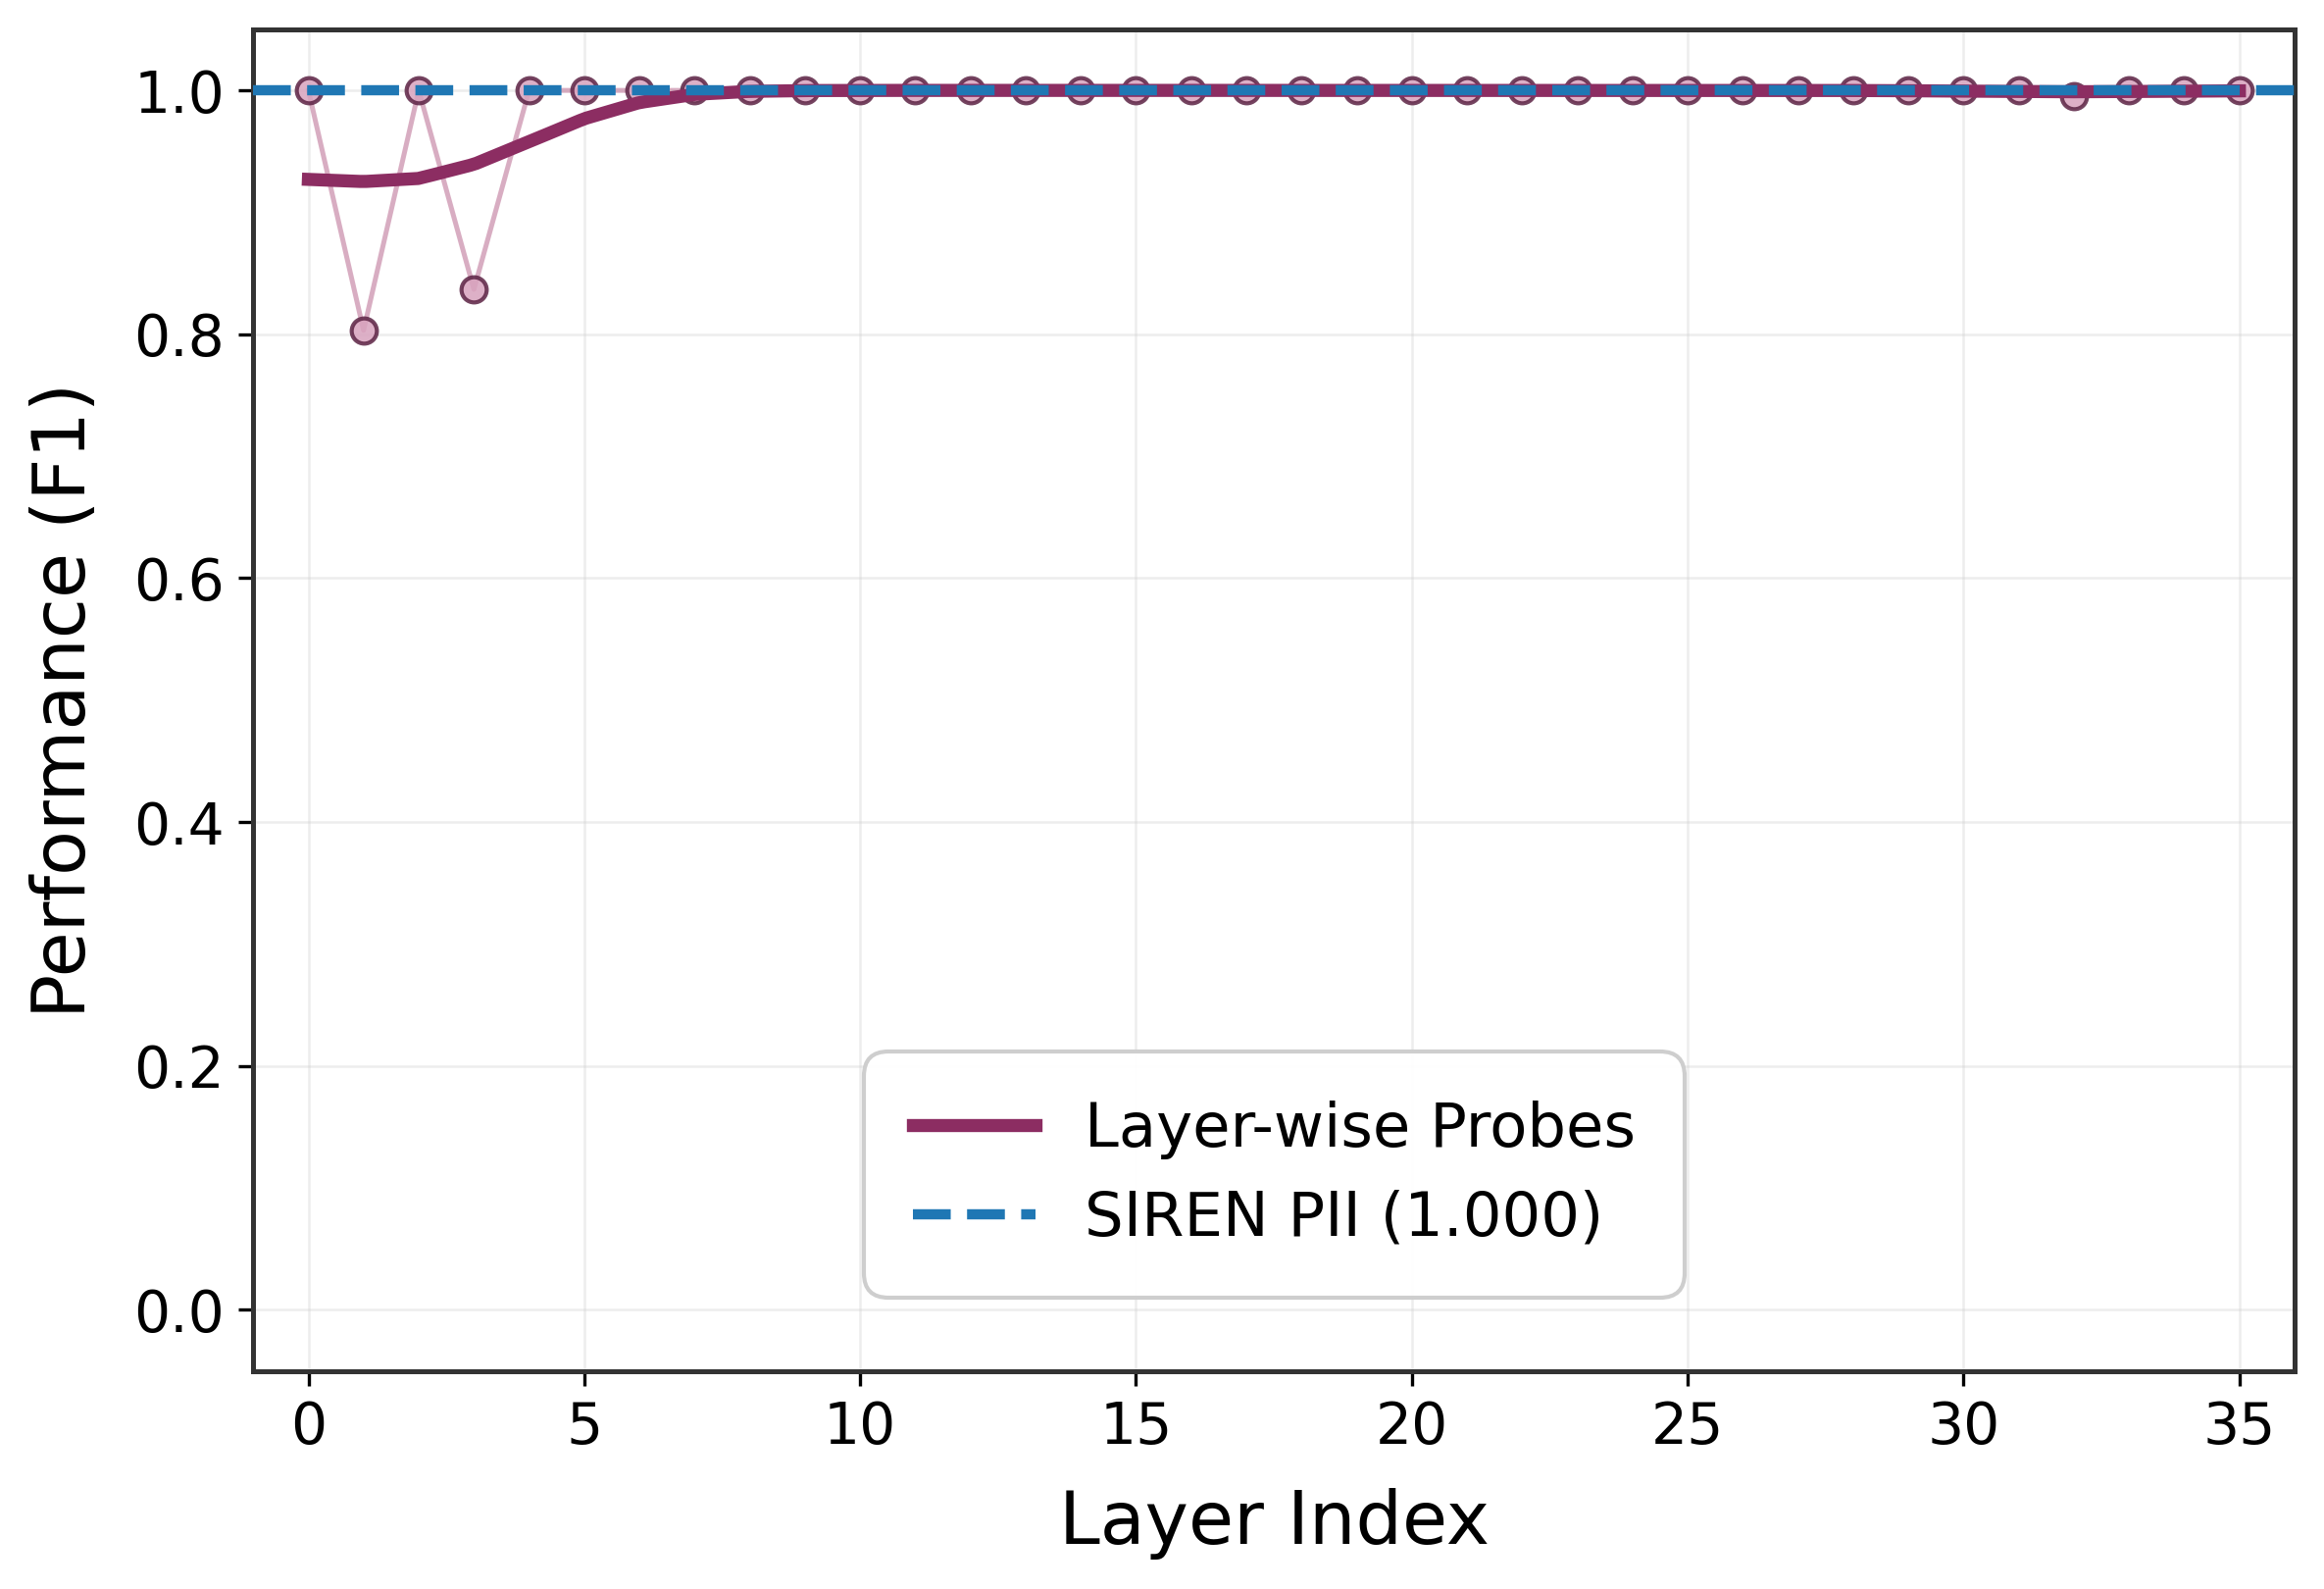

In [5]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)
ax.grid(True, linestyle='-', linewidth=0.6, alpha=0.35, color='#CCCCCC', zorder=1)

x_indices = np.arange(num_layers)

# 1. 探针散点与轻量连线
ax.plot(x_indices, f1_vals, color='#C88BA8', linewidth=1.2, alpha=0.7, zorder=2)
ax.scatter(x_indices, f1_vals, s=38, facecolors='#D8A3BE', edgecolors='#5C2344', linewidth=1.0, alpha=0.85, zorder=3)

# 2. LOESS / 高斯核平滑趋势主线 (深紫红 #8C2D62)
if num_layers > 4:
    x_smooth = np.linspace(0, num_layers - 1, 300)
    y_smooth = gaussian_filter1d(f1_vals, sigma=1.8)
    y_smooth_interp = np.interp(x_smooth, x_indices, y_smooth)
    ax.plot(x_smooth, y_smooth_interp, color='#8C2D62', linewidth=3.2, label='Layer-wise Probes', zorder=4)

# 3. SIREN PII 跨层融合基线 (蓝色虚线 #1F77B4)
ax.axhline(y=siren_pii_f1, color='#1F77B4', linestyle='--', linewidth=2.5, label=f'SIREN PII ({siren_pii_f1:.3f})', zorder=5)

ax.set_xlim(-1, num_layers)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Layer Index', fontsize=18, labelpad=8)
ax.set_ylabel('Performance (F1)', fontsize=18, labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=14)

legend = ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 0.05),
    fontsize=15,
    frameon=True,
    facecolor='white',
    edgecolor='#CCCCCC',
    framealpha=0.95
)
legend.get_frame().set_boxstyle('round,pad=0.4')

plt.tight_layout()
plt.savefig('pii_layerwise_performance.png', dpi=300, bbox_inches='tight')
plt.show()